In [1]:
import math
import numpy as np
import scipy.stats as ss
import scipy.linalg as sl
import matplotlib.pyplot as plt

rng = np.random.default_rng(30)

SIR Model

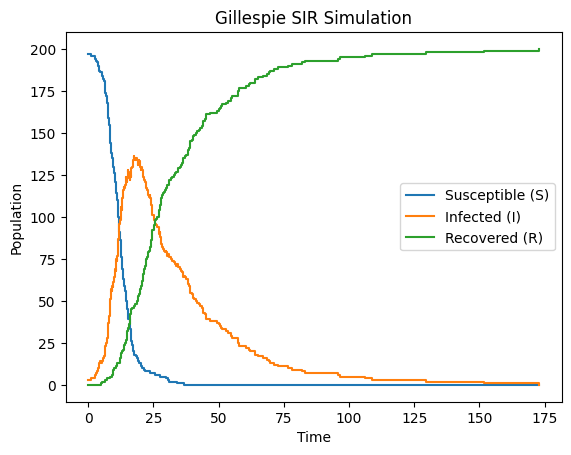

In [ ]:
rng = np.random.default_rng(30)

def gillespie_SIR(s0, i0, r0, beta, gamma, t_tot, rng):
    """
    Gillespie simulation of the SIR model

    Inputs:
    s0 is the initial number of susceptible individuals
    i0 is the initial number of infected people
    r0 is the initial number of people who recovered
    beta is the infection rate
    gamma is the recovery rate
    t_tot is the duration of the simulation

    Outputs:
    T is the list of times
    S, I and R are the number of people in each compartments at each t
    """

    # Start at time t0
    s, i, r = s0, i0, r0
    t = 0
    T = [t]
    S = [s]
    I = [i]
    R = [r]
    n = s + i + r

    while t < t_tot and i > 0:

        a_infect = beta * s * i / n
        a_recover = gamma * i
        a0 = a_infect + a_recover

        t += -np.log(rng.random()) / a0        # Time until the next event
        event = rng.random() * a0              # Choose the event

        if event < a_infect:                   # Infection event
            if s > 0:
                s -= 1
                i += 1
        else:                                  # Recovery event
            if i > 0:
                i -= 1
                r += 1

        T.append(t)
        S.append(s)
        I.append(i)
        R.append(r)

    return T, S, R, I

s0 = 197
i0 = 3
r0 = 0
beta = 0.4          # infection rate
gamma = 0.04        # recovery rate
mu = 0.005          # death rate
t_tot = 10000
T, S, R, I = gillespie_SIR(s0, i0, r0, beta, gamma, t_tot, rng)

plt.step(T, S, where='post', label='Susceptible (S)')
plt.step(T, I, where='post', label='Infected (I)')
plt.step(T, R, where='post', label='Recovered (R)')
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Gillespie SIR Simulation")
plt.legend()
plt.show()

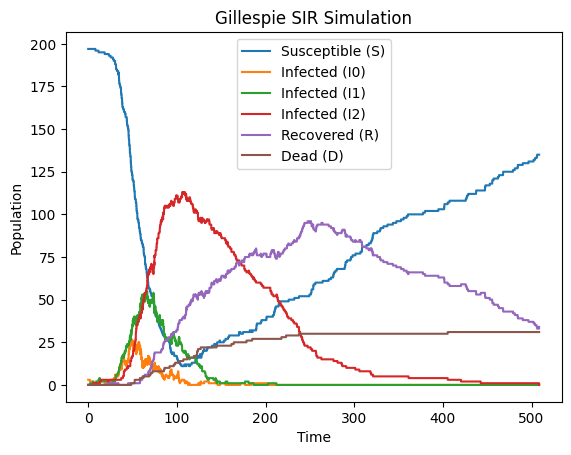

In [19]:
rng = np.random.default_rng(30)

def gillespie_SIR_2a(s_init, i0_init, beta, gamma, rho, xi, t_tot, rng):
    """
    Gillespie simulation of the SIR model

    Inputs:
    s0 is the initial number of susceptible individuals
    i0 is the initial number of infected people
    r0 is the initial number of people who recovered
    beta is the infection rate
    gamma is the recovery rate
    t_tot is the duration of the simulation

    Outputs:
    T is the list of times
    S, I and R are the number of people in each compartments at each t
    """

    # Start at time t0
    s, i0, i1, i2, r, d = s_init, i0_init, 0, 0, 0, 0
    t = 0
    T = [t]
    S = [s]
    I0 = [i0]
    I1 = [i1]
    I2 = [i2]
    R = [r]
    D = [d]

    beta0, beta1 = beta
    mu1, mu2 = mu
    rho0, rho1 = rho

    while t < t_tot and (i0 + i1 + i2) > 0:

        n = s + i0 + i1 + i2 + r0  # D excluded

        # Susceptible people can infected at rates...
        a_inf0 = beta0 * s * i0 / n
        a_inf1 = beta1 * s * i1 / n

        # Infected people can see their infection evolve at rates...
        a_prog0 = rho0 * i0
        a_prog1 = rho1 * i1

        # Infected people can die at rates...
        a_death1 = mu1 * i1
        a_death2 = mu2 * i2

        # Infected people can recover and thier immunity can evolve at rates...
        a_rec = gamma * i2

        # People who recovered can be susceptible again at rate...
        a_sus = xi * r

        # Total rate
        a0 = (a_inf0 + a_inf1 + a_prog0 + a_prog1 + a_death1 + a_death2 + a_rec + a_sus)
        if a0 == 0:
            break

        # choose random time step
        t += - np.log(rng.random()) / a0

        # choose the next event
        event = rng.random() * a0

        c = 0.0
        c += a_inf0
        if event < c:
            if s > 0:
                s -= 1
                i0 += 1

        else:
            c += a_inf1
            if event < c:
                if s > 0:
                    s -= 1
                    i0 += 1

            else:
                c += a_prog0
                if event < c:
                    if i0 > 0:
                        i0 -= 1
                        i1 += 1

                else:
                    c += a_prog1
                    if event < c:
                        if i1 > 0:
                            i1 -= 1
                            i2 += 1

                    else:
                        c += a_death1
                        if event < c:
                            if i1 > 0:
                                i1 -= 1
                                d += 1

                        else:
                            c += a_death2
                            if event < c:
                                if i2 > 0:
                                    i2 -= 1
                                    d += 1

                            else:
                                c += a_rec
                                if event < c:
                                    if i2 > 0:
                                        i2 -= 1
                                        r += 1

                                else:
                                    # xi: R1 → S
                                    if r > 0:
                                        r -= 1
                                        s += 1

        T.append(t)
        S.append(s)
        I0.append(i0)
        I1.append(i1)
        I2.append(i2)
        R.append(r)
        D.append(d)

    return T, S, I0, I1, I2, R, D

s_init = 197
i0_init = 3
r0 = 0
beta = (0.05, 0.15)            # infection rates
gamma = 0.01                    # recovery rate
mu = (0.004, 0.001)            # death rate
rho = (0.2, 0.05)
xi = 0.005
t_tot = 10000
T, S, I0, I1, I2, R, D = gillespie_SIR_2a(s_init, i0_init, beta, gamma, rho, xi, t_tot, rng)

plt.step(T, S, where='post', label='Susceptible (S)')
plt.step(T, I0, where='post', label='Infected (I0)')
plt.step(T, I1, where='post', label='Infected (I1)')
plt.step(T, I2, where='post', label='Infected (I2)')
plt.step(T, R, where='post', label='Recovered (R)')
plt.step(T, D, where='post', label='Dead (D)')
plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Gillespie SIR Simulation")
plt.legend()
plt.show()
